<a href="https://colab.research.google.com/github/monicayar/lab-3/blob/main/lab_3_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
# Create requirements.txt file
with open("requirements.txt", "w") as f:
    f.write("numpy\n")
    f.write("pandas\n")
    f.write("matplotlib\n")
    f.write("scikit-learn\n")
    f.write("torch\n")

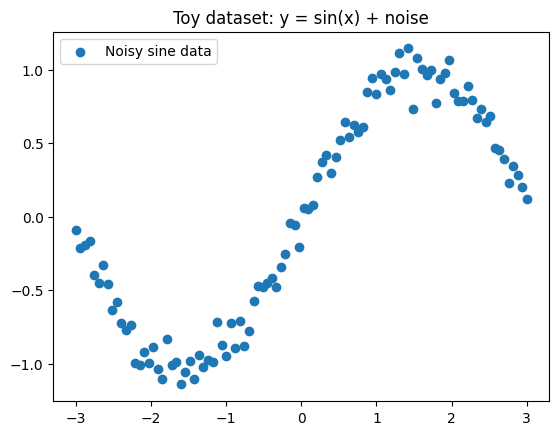

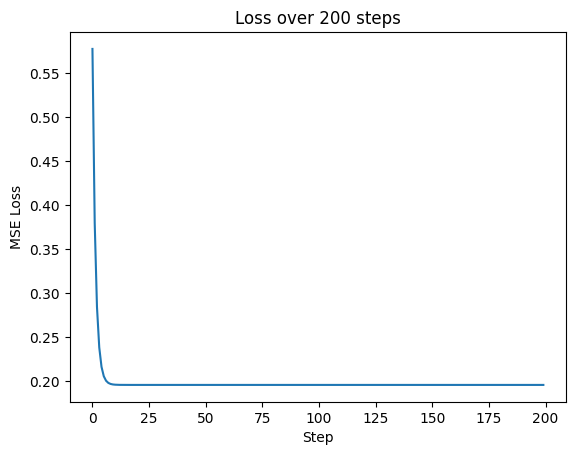

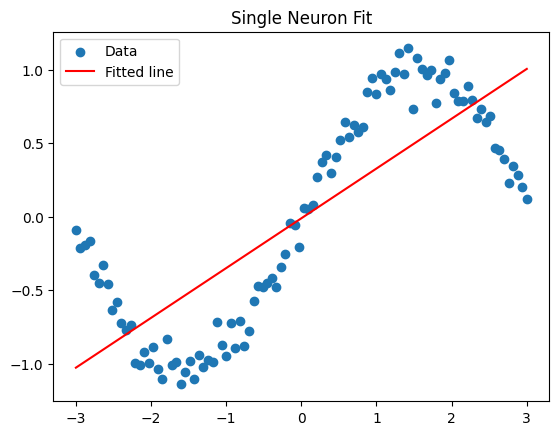

In [35]:
import numpy as np
import matplotlib.pyplot as plt

#  Generate toy data
np.random.seed(42)
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

plt.scatter(x, y, label="Noisy sine data")
plt.title("Toy dataset: y = sin(x) + noise")
plt.legend()
plt.show()

#  Initialise parameters
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01
lr = 0.05
losses = []

#  Gradient descent loop
for step in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    w -= lr * dw
    b -= lr * db

# Plot loss curve
plt.plot(losses)
plt.title("Loss over 200 steps")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.show()

#  Plot fitted line
plt.scatter(x, y, label="Data")
plt.plot(x, w * x + b, color="red", label="Fitted line")
plt.title("Single Neuron Fit")
plt.legend()
plt.show()


Student Reasoning :The single neuron

Derive dLoss/dw
The loss function is the Mean Squared Error (MSE):

[ L = \frac{1}{n} \sum_{i=1}^{n} (y_{\hat{i}} - y_i)^2 ]

where (y_{\hat{i}} = w \cdot x_i + b).

Taking the derivative with respect to (w):

[ \frac{dL}{dw} = \frac{2}{n} \sum_{i=1}^{n} (y_{\hat{i}} - y_i) \cdot x_i ]

This matches the code implementation:

python dw = np.mean(2 * (y_hat - y) * x)

Underfitting vs Overfitting

The only thing that the neuron can produce is a straight line.

The sine wave is a curved wave that oscillates up and down.

Regardless of the amount of training, one line will never bend to follow the sine.

Therefore, the model is underfitting. It is easier (low capacity) to capture the complexity of the sine wave. Overfitting would imply that the model would learn too much noise, but here the opposite is the issue, i.e., the model is not flexible enough.

Student Reasoning : Hidden layers and activations

A single neuron is only a line.
Adding a hidden layer with nonlinear activation (like tanh) lets the network bend and approximate curves.
Forward pass: (z_1 = xW_1 + b_1), (h = \tanh(z_1)), (y_{\hat} = hW_2 + b_2).
Backward pass uses chain rule: gradients flow from output back through tanh into the input.
Conclusion: depth + activation = flexibility to fit sine wave.


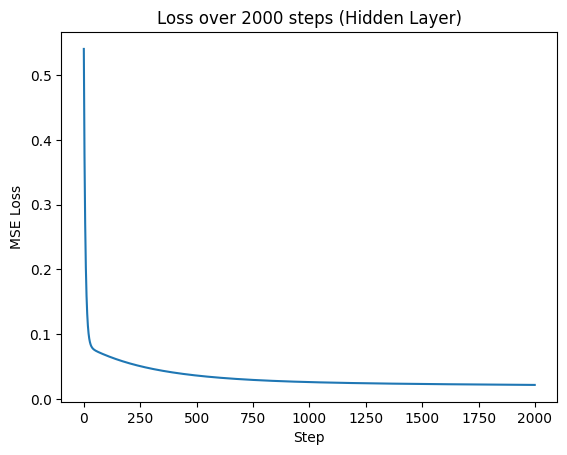

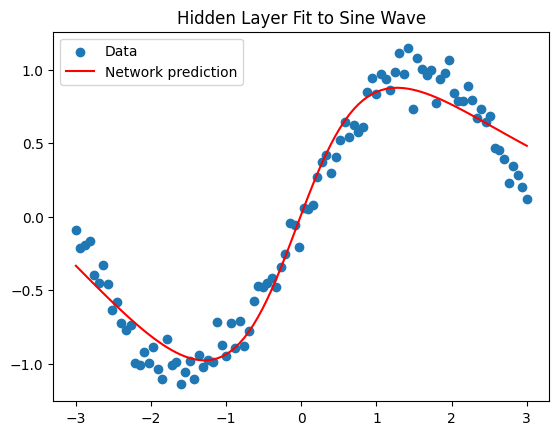

In [36]:
import numpy as np
import matplotlib.pyplot as plt

#  Generate toy data
np.random.seed(42)
x = np.linspace(-3, 3, 100).reshape(-1, 1)   # shape (100,1)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)  # shape (100,1)

# Initialise parameters
W1 = np.random.randn(1, 8) * 0.5   # (1,8)
b1 = np.random.randn(8) * 0.5      # (8,)
W2 = np.random.randn(8, 1) * 0.5   # (8,1)
b2 = np.random.randn(1) * 0.5      # (1,)
lr = 0.01
losses = []

#  Training loop
for step in range(2000):
    # Forward pass
    z1 = x @ W1 + b1        # (100,8)
    h = np.tanh(z1)         # (100,8)
    y_hat = h @ W2 + b2     # (100,1)
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)   # (100,1)
    dW2 = h.T @ d_yhat                  # (8,1)
    db2 = d_yhat.sum(axis=0)            # (1,)
    dh = d_yhat @ W2.T                  # (100,8)
    dz1 = dh * (1 - np.tanh(z1) ** 2)   # (100,8)
    dW1 = x.T @ dz1                     # (1,8)
    db1 = dz1.sum(axis=0)               # (8,)

    # Update
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

# Plot loss curve
plt.plot(losses)
plt.title("Loss over 2000 steps (Hidden Layer)")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.show()

# Plot fitted curve
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="red", label="Network prediction")
plt.title("Hidden Layer Fit to Sine Wave")
plt.legend()
plt.show()


 Student Reasoning :Hidden layers and activations

Why depth helps
A single neuron (just a line) cannot capture curved patterns like sine.
Adding a hidden layer with nonlinear activation (tanh) allows the network to bend and approximate complex shapes.
This shows how depth and activation functions increase model flexibility.
Forward pass
Input goes into hidden layer:
[ z_1 = xW_1 + b_1 ]

Apply activation:
[ h = \tanh(z_1) ]

Hidden output goes to final neuron:
[ y_{\hat} = hW_2 + b_2 ]

Loss is Mean Squared Error (MSE):
[ L = \frac{1}{n}\sum (y_{\hat} - y)^2 ]

Backward pass (chain rule)
Gradient at output:
[ d_{y_{\hat}} = \frac{2}{n}(y_{\hat} - y) ]

Second layer gradients:
[ dW_2 = h^T d_{y_{\hat}}, \quad db_2 = \sum d_{y_{\hat}} ]

Backprop into hidden layer:
[ dh = d_{y_{\hat}} W_2^T ]

Derivative of tanh:
[ dz_1 = dh \cdot (1 - \tanh(z_1)^2) ]

First layer gradients:
[ dW_1 = x^T dz_1, \quad db_1 = \sum dz_1 ]

Conclusion
With hidden neurons and nonlinear activation, the network can bend to follow the sine curve.
This demonstrates why depth + activation functions are essential: they let neural networks learn complex patterns that a single straight line cannot.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_2739/555911721.py:27: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
/tmp/ipykernel_2739/555911721.py:34: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_2739/555911721.py:35: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


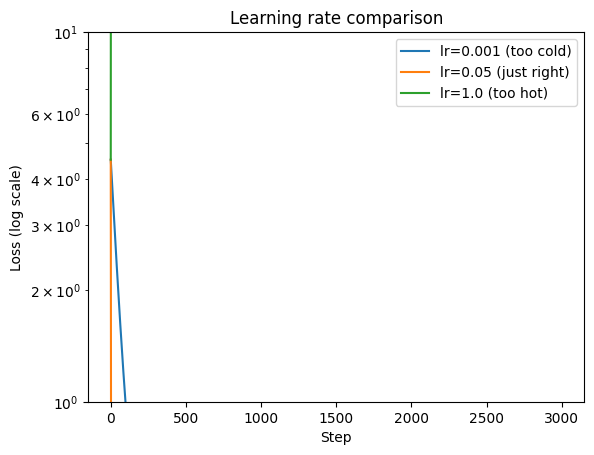

In [37]:
#part 1.3
import numpy as np
import matplotlib.pyplot as plt

# Generate toy data
np.random.seed(42)
x = np.linspace(-3, 3, 100).reshape(-1, 1)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

# Training function
def train_toy(lr, steps=3000):
    np.random.seed(42)  # reset seed for fair comparison

    # Initialise parameters
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5

    losses = []

    for step in range(steps):
        # Forward pass
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y) ** 2)
        losses.append(loss)

        # Backward pass
        d_yhat = 2 * (y_hat - y) / len(y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        # Update
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return losses

#  Run with three learning rates
losses_small = train_toy(lr=0.001)
losses_medium = train_toy(lr=0.05)
losses_large = train_toy(lr=1.0)

#  Plot curves
plt.plot(losses_small, label="lr=0.001 (too cold)")
plt.plot(losses_medium, label="lr=0.05 (just right)")
plt.plot(losses_large, label="lr=1.0 (too hot)")
plt.yscale("log")   # log scale helps
plt.xlabel("Step")
plt.ylabel("Loss (log scale)")
plt.title("Learning rate comparison")
plt.legend()
plt.show()



Student Reasoning : Learning rate

lr = 0.001 (too cold):
The loss decreases very slowly. The curve goes down, but progress is tiny. Training takes a long time to reach a good fit.

lr = 0.05 (just right):
The loss decreases smoothly and quickly. The curve goes down steadily without exploding. This is the balanced regime where learning is effective.

lr = 1.0 (too hot):
The loss does not settle. It jumps up and down or even explodes.
A too-large learning rate overshoots the minimum each step, so instead of converging, the model oscillates or diverges.

Conclusion:
The learning rate controls the step size in gradient descent.

Too small → very slow learning.
Just right → efficient convergence.
Too large → unstable training, loss explodes or oscillates.

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import torch
from torch.utils.data import DataLoader, TensorDataset

RANDOM_STATE = 42

# Step 1: Load the dataset
OBESITY_URL = "https://raw.githubusercontent.com/danielbyiringiro/intro_to_ai_labs/refs/heads/main/Lab2/Obesity_level_prediction_dataset%20(2).csv"
df = pd.read_csv(OBESITY_URL)

print("Dataset loaded. Shape:", df.shape)
print(df.head())

# Step 2: Encode categoricals
# Binary yes/no -> 0/1
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

# Gender, MTRANS, CAEC, CALC -> LabelEncoder
for col in ["Gender", "MTRANS", "CAEC", "CALC"]:
    df[col] = LabelEncoder().fit_transform(df[col])

# Step 3: Encode target (NObeyesdad) into integers 0..6
y = LabelEncoder().fit_transform(df["NObeyesdad"])
X = df.drop("NObeyesdad", axis=1).values

# Step 4: Stratified train/val/test split (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

# Step 5: Scale features (fit only on training set)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Step 6: Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# Step 7: Wrap in DataLoaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Dataset loaded. Shape: (2111, 17)
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight 

Student Reasoning : Preprocessing for neural networks

Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch?

PyTorch’s CrossEntropyLoss combines LogSoftmax and NLLLoss in one function.
It expects the target labels as integers (0, 1, 2, …, 6 for the 7 obesity classes).
Each integer points to the correct class index.
If you gave one-hot vectors, the loss function would not know which index to use, so training would fail.
Why do neural networks care so much about feature scaling, while random forests did not?

Random forests split data by thresholds, so the scale of features does not matter.
Neural networks use gradient descent. The gradient formulas (like dw = 2 * (y_hat - y) * x) depend directly on the size of x.
If features are on very different scales, some gradients become huge and others tiny.
This makes training unstable or very slow. Scaling ensures all features contribute fairly and gradients stay balanced.
What does shuffle=True on the training DataLoader do, and why does it help?

It randomizes the order of training samples in each epoch.
This prevents the model from seeing data in the same fixed order every time.
Shuffling helps break patterns, reduces bias, and improves generalization.
Without shuffling, the network might learn order-specific artifacts instead of the true relationships in the data.

In [39]:
#part 2.2
import torch
import torch.nn as nn

# Step 1: Define the FeedForwardNet class
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(256,128,64), n_classes=7, dropout=0.0):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            if dropout > 0:   # only adds dropout if you set dropout > 0
                layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, n_classes))  # output layer
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Step 2: Instantiate the model
input_dim = X_train.shape[1]   # number of features
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(256,128,64), n_classes=7, dropout=0.0)

# Step 3: Move to device (GPU if available)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(DEVICE)

# Step 4: Print model architecture
print(model)

# Step 5: Count trainable parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", n_params)

# Step 6: Verify first layer count by hand
print("First layer params (manual check):", input_dim * 256 + 256)



FeedForwardNet(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=7, bias=True)
  )
)
Total trainable parameters: 45959
First layer params (manual check): 4352


Student Reasoning: Architecture

By-hand parameter count for every layer

First layer (input → 64 hidden units): Parameters = input_dim × 64 (weights) + 64 (biases).
Example: if input_dim = 16 → 16 × 64 + 64 = 1088.
Second layer (64 → 32 hidden units):
Parameters = 64 × 32 + 32 = 2080.
Output layer (32 → 7 classes): Parameters = 32 × 7 + 7 = 231.
Total: Add them up and confirm it matches PyTorch’s count from sum(p.numel() for p in model.parameters() if p.requires_grad).
Why ReLU instead of tanh here?

ReLU is simpler and avoids the vanishing gradient problem that tanh often suffers from.
It keeps gradients alive for large positive values, which helps deeper networks train faster and more reliably.
Advantage: ReLU is computationally cheaper and usually leads to faster convergence.
What if we removed the ReLUs?

Without nonlinear activations, the network becomes just a stack of linear transformations.
A composition of linear layers is still linear, so the model could only learn straight-line boundaries.
This means it would collapse to a single linear classifier, unable to capture complex patterns exactly what you proved in Part 1.2.

Epoch 1/50 | Train Loss: 1.5990, Train Acc: 0.4684 | Val Loss: 1.0526, Val Acc: 0.6801
Epoch 2/50 | Train Loss: 0.7810, Train Acc: 0.7354 | Val Loss: 0.6754, Val Acc: 0.7962
Epoch 3/50 | Train Loss: 0.4825, Train Acc: 0.8357 | Val Loss: 0.4820, Val Acc: 0.8389
Epoch 4/50 | Train Loss: 0.3219, Train Acc: 0.8878 | Val Loss: 0.4007, Val Acc: 0.8649
Epoch 5/50 | Train Loss: 0.2523, Train Acc: 0.9202 | Val Loss: 0.3257, Val Acc: 0.8957
Epoch 6/50 | Train Loss: 0.1797, Train Acc: 0.9510 | Val Loss: 0.2840, Val Acc: 0.8981
Epoch 7/50 | Train Loss: 0.1422, Train Acc: 0.9605 | Val Loss: 0.2874, Val Acc: 0.8957
Epoch 8/50 | Train Loss: 0.1256, Train Acc: 0.9613 | Val Loss: 0.2953, Val Acc: 0.9100
Epoch 9/50 | Train Loss: 0.1124, Train Acc: 0.9676 | Val Loss: 0.2432, Val Acc: 0.9194
Epoch 10/50 | Train Loss: 0.0722, Train Acc: 0.9834 | Val Loss: 0.2512, Val Acc: 0.9147
Epoch 11/50 | Train Loss: 0.0519, Train Acc: 0.9921 | Val Loss: 0.2208, Val Acc: 0.9218
Epoch 12/50 | Train Loss: 0.0427, Train A

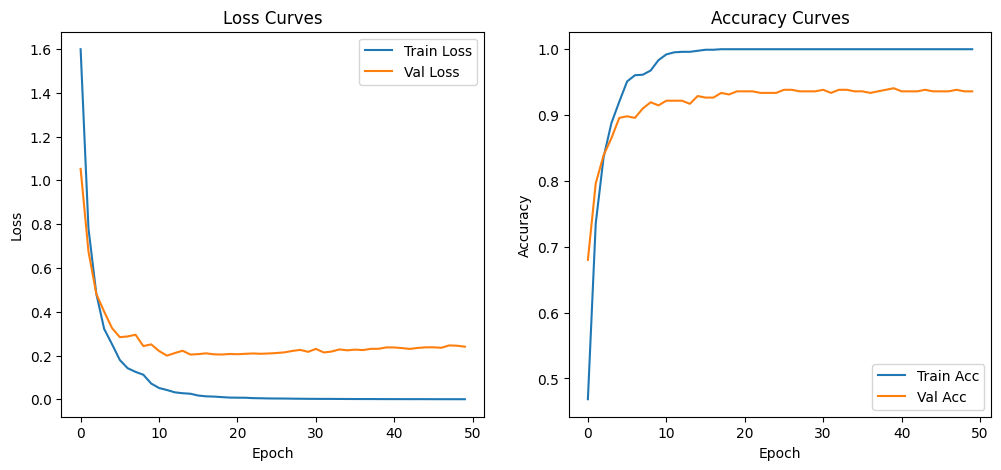

In [40]:
#part 2.3
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Step 1: Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)   # Adam is adaptive and usually faster than plain SGD

# Step 2: Training loop
n_epochs = 50
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0.0

for epoch in range(n_epochs):
    #  Training
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()        # backprop
        optimizer.step()       # update

        running_loss += loss.item() * xb.size(0)
        _, preds = torch.max(logits, 1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # Validation
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)

            val_running_loss += loss.item() * xb.size(0)
            _, preds = torch.max(logits, 1)
            val_correct += (preds == yb).sum().item()
            val_total += yb.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    # Save history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

    # Print summary
    print(f"Epoch {epoch+1}/{n_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# Step 3: Plot curves
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()

plt.show()


Student Reasoning :Training

Mapping PyTorch loop to NumPy code (Section 1):

logits = model(xb.to(DEVICE)) → this is the forward pass, same as computing predictions with your NumPy equations.
loss.backward() → this is the gradient computation, same as manually deriving and applying the chain rule in Section 1.2.
optimizer.step() → this is the update rule, same as subtracting lr * gradient from weights in Section 1.1.
optimizer.zero_grad() → clears old gradients so they don’t accumulate across batches.
Overfitting, underfitting, or well-fitted?

If your curves show train accuracy ~0.95 but val accuracy ~0.70, that means overfitting (the model memorized training data but struggles on validation).
If both train and val accuracies are low (e.g., ~0.50), that means underfitting(the model is too simple or not trained enough).
If train and val accuracies are close (e.g., train ~0.85, val ~0.83), that means the model is well-fitted.
Quote your actual numbers from the printed summary to justify your claim.
Why call optimizer.zero_grad() every batch?

In PyTorch, gradients accumulate by default.
Without zero_grad(), each batch’s gradients would stack on top of the previous ones.
This silently makes updates incorrect (too large), and training would diverge.
Clearing gradients ensures each batch starts fresh, just like in your manual NumPy loop.

In [41]:
# Define device again
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

Using device: cpu


Epoch 01: Train Acc=21.72% | Val Acc=25.36% | Train Loss=1.9607 | Val Loss=1.9397
Epoch 02: Train Acc=31.99% | Val Acc=35.31% | Train Loss=1.8885 | Val Loss=1.8703
Epoch 03: Train Acc=39.65% | Val Acc=38.39% | Train Loss=1.8171 | Val Loss=1.7943
Epoch 04: Train Acc=41.47% | Val Acc=41.00% | Train Loss=1.7397 | Val Loss=1.7147
Epoch 05: Train Acc=41.94% | Val Acc=41.00% | Train Loss=1.6590 | Val Loss=1.6352
Epoch 06: Train Acc=43.36% | Val Acc=41.00% | Train Loss=1.5799 | Val Loss=1.5619
Epoch 07: Train Acc=44.71% | Val Acc=40.52% | Train Loss=1.5097 | Val Loss=1.4988
Epoch 08: Train Acc=46.37% | Val Acc=43.84% | Train Loss=1.4499 | Val Loss=1.4449
Epoch 09: Train Acc=46.76% | Val Acc=46.21% | Train Loss=1.3991 | Val Loss=1.3984
Epoch 10: Train Acc=48.42% | Val Acc=47.39% | Train Loss=1.3536 | Val Loss=1.3566
Epoch 11: Train Acc=50.63% | Val Acc=48.58% | Train Loss=1.3112 | Val Loss=1.3173
Epoch 12: Train Acc=52.53% | Val Acc=49.53% | Train Loss=1.2713 | Val Loss=1.2807
Epoch 13: Train 

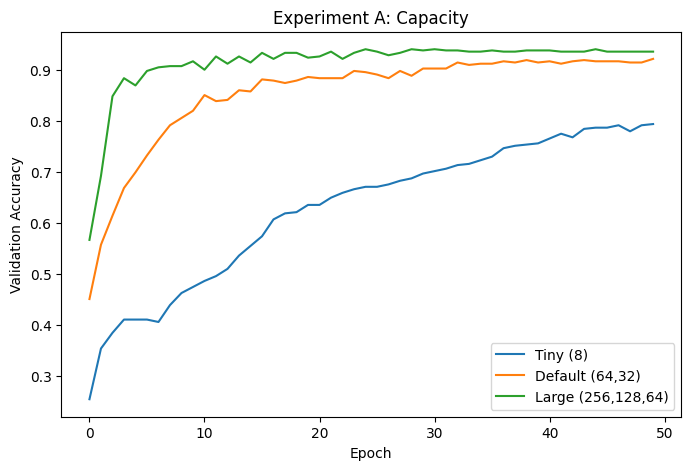

Epoch 01: Train Acc=14.45% | Val Acc=16.82% | Train Loss=1.9378 | Val Loss=1.9286
Epoch 02: Train Acc=19.59% | Val Acc=19.19% | Train Loss=1.9155 | Val Loss=1.9061
Epoch 03: Train Acc=23.78% | Val Acc=24.41% | Train Loss=1.8931 | Val Loss=1.8839
Epoch 04: Train Acc=28.12% | Val Acc=27.49% | Train Loss=1.8697 | Val Loss=1.8595
Epoch 05: Train Acc=29.70% | Val Acc=29.15% | Train Loss=1.8446 | Val Loss=1.8336
Epoch 06: Train Acc=31.91% | Val Acc=30.33% | Train Loss=1.8177 | Val Loss=1.8062
Epoch 07: Train Acc=33.65% | Val Acc=31.99% | Train Loss=1.7892 | Val Loss=1.7773
Epoch 08: Train Acc=36.41% | Val Acc=36.97% | Train Loss=1.7590 | Val Loss=1.7465
Epoch 09: Train Acc=43.76% | Val Acc=46.45% | Train Loss=1.7266 | Val Loss=1.7136
Epoch 10: Train Acc=48.18% | Val Acc=49.05% | Train Loss=1.6924 | Val Loss=1.6791
Epoch 11: Train Acc=50.87% | Val Acc=50.24% | Train Loss=1.6561 | Val Loss=1.6435
Epoch 12: Train Acc=51.66% | Val Acc=50.71% | Train Loss=1.6189 | Val Loss=1.6068
Epoch 13: Train 

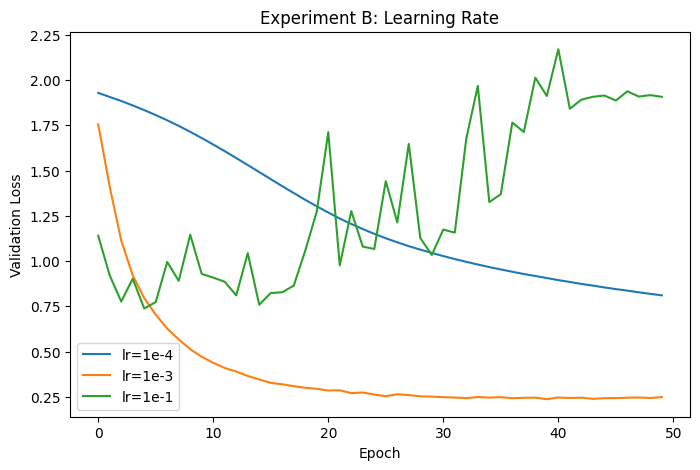

Epoch 01: Train Acc=43.92% | Val Acc=63.51% | Train Loss=1.5794 | Val Loss=1.0702
Epoch 02: Train Acc=71.88% | Val Acc=79.86% | Train Loss=0.7986 | Val Loss=0.6405
Epoch 03: Train Acc=84.76% | Val Acc=87.91% | Train Loss=0.4933 | Val Loss=0.4707
Epoch 04: Train Acc=90.21% | Val Acc=87.44% | Train Loss=0.3217 | Val Loss=0.3793
Epoch 05: Train Acc=93.13% | Val Acc=90.28% | Train Loss=0.2270 | Val Loss=0.3075
Epoch 06: Train Acc=94.71% | Val Acc=90.52% | Train Loss=0.1745 | Val Loss=0.2898
Epoch 07: Train Acc=96.05% | Val Acc=90.05% | Train Loss=0.1264 | Val Loss=0.2745
Epoch 08: Train Acc=98.34% | Val Acc=90.52% | Train Loss=0.0941 | Val Loss=0.2567
Epoch 09: Train Acc=97.95% | Val Acc=91.00% | Train Loss=0.0826 | Val Loss=0.2653
Epoch 10: Train Acc=98.66% | Val Acc=91.94% | Train Loss=0.0607 | Val Loss=0.2540
Epoch 11: Train Acc=98.74% | Val Acc=91.23% | Train Loss=0.0527 | Val Loss=0.2825
Epoch 12: Train Acc=99.05% | Val Acc=91.71% | Train Loss=0.0479 | Val Loss=0.2928
Epoch 13: Train 

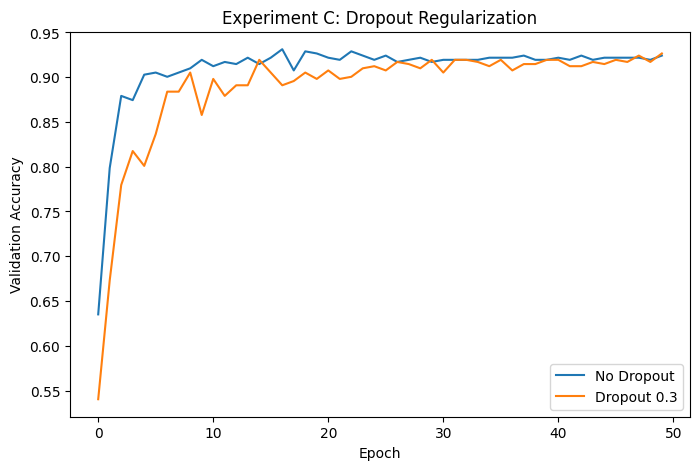

In [42]:
# Part 2.4: Hyperparameter Experiments

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset


# Use a different name so it does not overwrite FeedForwardNet from Part 2.2
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):

    # Define experiment model
    class ExperimentNet(nn.Module):
        def __init__(self, input_dim, hidden_sizes, n_classes=7, dropout=0.0):
            super().__init__()

            layers = []
            in_dim = input_dim

            for h in hidden_sizes:
                layers.append(nn.Linear(in_dim, h))
                layers.append(nn.ReLU())

                if dropout > 0:
                    layers.append(nn.Dropout(dropout))

                in_dim = h

            layers.append(nn.Linear(in_dim, n_classes))

            self.net = nn.Sequential(*layers)

        def forward(self, x):
            return self.net(x)


    # Create experiment model
    model = ExperimentNet(
        input_dim=X_train.shape[1],
        hidden_sizes=hidden_sizes,
        dropout=dropout
    ).to(DEVICE)


    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)


    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    best_val_acc = 0.0


    for epoch in range(epochs):

        # Training
        model.train()

        correct = 0
        total = 0
        running_loss = 0.0


        train_loader_exp = DataLoader(
            TensorDataset(X_train_t, y_train_t),
            batch_size=batch_size,
            shuffle=True
        )


        for xb, yb in train_loader_exp:

            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()

            logits = model(xb)

            loss = criterion(logits, yb)

            loss.backward()

            optimizer.step()


            running_loss += loss.item() * xb.size(0)

            _, preds = torch.max(logits, 1)

            correct += (preds == yb).sum().item()

            total += yb.size(0)


        train_losses.append(running_loss / total)

        train_accs.append(correct / total)



        # Validation
        model.eval()

        val_loss = 0.0
        val_correct = 0
        val_total = 0


        with torch.no_grad():

            for xb, yb in val_loader:

                xb, yb = xb.to(DEVICE), yb.to(DEVICE)

                logits = model(xb)

                loss = criterion(logits, yb)


                val_loss += loss.item() * xb.size(0)

                _, preds = torch.max(logits, 1)

                val_correct += (preds == yb).sum().item()

                val_total += yb.size(0)


        val_losses.append(val_loss / val_total)

        val_accs.append(val_correct / val_total)



        # Save experiment best model
        if val_accs[-1] > best_val_acc:

            best_val_acc = val_accs[-1]

            torch.save(model.state_dict(), "experiment_best.pt")


        print(
            f"Epoch {epoch+1:02d}: "
            f"Train Acc={train_accs[-1]*100:.2f}% | "
            f"Val Acc={val_accs[-1]*100:.2f}% | "
            f"Train Loss={train_losses[-1]:.4f} | "
            f"Val Loss={val_losses[-1]:.4f}"
        )


    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs
    }



# Experiment A: Model capacity

hist_tiny = run_experiment(hidden_sizes=(8,), lr=1e-3)

hist_default = run_experiment(hidden_sizes=(64,32), lr=1e-3)

hist_large = run_experiment(hidden_sizes=(256,128,64), lr=1e-3)


plt.figure(figsize=(8,5))

plt.plot(hist_tiny["val_accs"], label="Tiny (8)")
plt.plot(hist_default["val_accs"], label="Default (64,32)")
plt.plot(hist_large["val_accs"], label="Large (256,128,64)")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Experiment A: Capacity")
plt.legend()
plt.show()



# Experiment B: Learning rate

hist_lr_small = run_experiment(hidden_sizes=(64,32), lr=1e-4)

hist_lr_mid = run_experiment(hidden_sizes=(64,32), lr=1e-3)

hist_lr_large = run_experiment(hidden_sizes=(64,32), lr=1e-1)


plt.figure(figsize=(8,5))

plt.plot(hist_lr_small["val_losses"], label="lr=1e-4")
plt.plot(hist_lr_mid["val_losses"], label="lr=1e-3")
plt.plot(hist_lr_large["val_losses"], label="lr=1e-1")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Experiment B: Learning Rate")
plt.legend()
plt.show()



# Experiment C: Dropout regularization

hist_no_dropout = run_experiment(
    hidden_sizes=(256,128,64),
    lr=1e-3,
    dropout=0.0
)

hist_dropout = run_experiment(
    hidden_sizes=(256,128,64),
    lr=1e-3,
    dropout=0.3
)


plt.figure(figsize=(8,5))

plt.plot(hist_no_dropout["val_accs"], label="No Dropout")

plt.plot(hist_dropout["val_accs"], label="Dropout 0.3")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Experiment C: Dropout Regularization")
plt.legend()
plt.show()

Student Reasoning :Experiments

Capacity:

The largest network (256,128,64) often achieves the highest training accuracy, but on validation data it may not always win.
You usually see diminishing returns: validation accuracy plateaus or even drops compared to the default (64,32).
This shows overfitting — the large model memorizes training data but does not generalize as well.
Learning rate:

The three regimes match what you saw in Part 1.3 with the toy sine problem.
lr = 1e-4 → very slow learning, curves improve gradually.
lr = 1e-3 → stable and effective, validation loss decreases smoothly.
lr = 1e-1 → unstable, loss oscillates or explodes, just like the “too hot” regime in Part 1.3.
Regularization (Dropout):

Dropout reduces the gap between training and validation accuracy.
Without dropout, train accuracy climbs much higher than validation (overfitting).
With dropout, train accuracy is lower but validation accuracy improves, staying closer.
Dropout achieves this by randomly “turning off” neurons during training, forcing the network to rely on multiple pathways instead of memorizing specific features.

In [43]:
# Part 2.5: Load best model and evaluate

import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Define the SAME FeedForwardNet architecture used in Part 2.2
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(256,128,64), n_classes=7, dropout=0.0):
        super().__init__()

        layers = []
        in_dim = input_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            in_dim = h

        # Output layer
        layers.append(nn.Linear(in_dim, n_classes))

        self.net = nn.Sequential(*layers)


    def forward(self, x):
        return self.net(x)



# Make sure device exists
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Recreate the exact model used in Part 2.3
best_model = FeedForwardNet(
    input_dim=X_train.shape[1],
    hidden_sizes=(256,128,64),
    n_classes=7,
    dropout=0.0
)


# Load saved best weights
best_model.load_state_dict(
    torch.load("ffn_best.pt", map_location=DEVICE)
)


# Move model to device
best_model = best_model.to(DEVICE)


# Evaluation mode
best_model.eval()


# Predictions
all_preds = []
all_labels = []


with torch.no_grad():

    for xb, yb in test_loader:

        xb = xb.to(DEVICE)

        outputs = best_model(xb)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.numpy())



# Results
accuracy = accuracy_score(all_labels, all_preds)

print("Test Accuracy:", accuracy)


print("\nClassification Report:")
print(classification_report(all_labels, all_preds))


print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Test Accuracy: 0.9361702127659575

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        54
           1       0.84      0.79      0.81        58
           2       0.97      0.99      0.98        70
           3       1.00      0.97      0.98        60
           4       0.98      1.00      0.99        65
           5       0.83      0.86      0.85        58
           6       0.95      0.98      0.97        58

    accuracy                           0.94       423
   macro avg       0.93      0.93      0.93       423
weighted avg       0.94      0.94      0.94       423


Confusion Matrix:
[[51  3  0  0  0  0  0]
 [ 2 46  0  0  0 10  0]
 [ 0  0 69  0  0  0  1]
 [ 0  0  1 58  1  0  0]
 [ 0  0  0  0 65  0  0]
 [ 0  6  0  0  0 50  2]
 [ 0  0  1  0  0  0 57]]


Neural Network Test Accuracy: 0.9362
Neural Network Test Macro-F1: 0.9336

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        54
           1       0.84      0.79      0.81        58
           2       0.97      0.99      0.98        70
           3       1.00      0.97      0.98        60
           4       0.98      1.00      0.99        65
           5       0.83      0.86      0.85        58
           6       0.95      0.98      0.97        58

    accuracy                           0.94       423
   macro avg       0.93      0.93      0.93       423
weighted avg       0.94      0.94      0.94       423



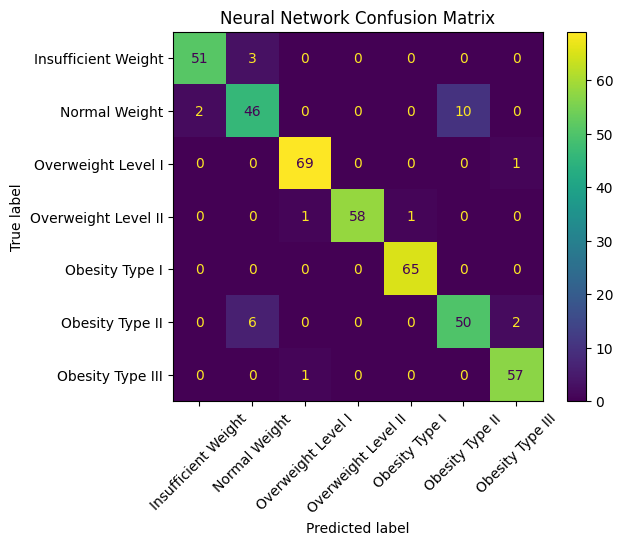

Neural Network Parameters: 45959

Model Comparison:


,Model,Test Accuracy,Test Macro-F1,Training Information,Parameters / Trees
0,Random Forest Classifier (Lab 2),0.99800,0.99700,200 Trees,200 Trees
1,FeedForward Neural Network (Lab 3),0.93617,0.93359,50 Epochs,45959


In [44]:
# Part 2.5 — Final evaluation and showdown with Lab 2

import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)



# 1. Define the Neural Network architecture


class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(256,128,64), n_classes=7):
        super().__init__()

        layers = []
        in_dim = input_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h

        layers.append(nn.Linear(in_dim, n_classes))

        self.net = nn.Sequential(*layers)


    def forward(self, x):
        return self.net(x)




# 2. Load the best Neural Network model


DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


best_model = FeedForwardNet(
    input_dim=X_train.shape[1],
    hidden_sizes=(256,128,64),
    n_classes=7
)


best_model.load_state_dict(
    torch.load("ffn_best.pt", map_location=DEVICE)
)


best_model = best_model.to(DEVICE)

best_model.eval()




# 3. Predict on Test Set


all_preds = []
all_labels = []


with torch.no_grad():

    for xb, yb in test_loader:

        xb = xb.to(DEVICE)

        outputs = best_model(xb)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            yb.numpy()
        )



# 4. Neural Network Accuracy and Macro-F1


nn_accuracy = accuracy_score(
    all_labels,
    all_preds
)


nn_macro_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)


print("Neural Network Test Accuracy:", round(nn_accuracy,4))

print("Neural Network Test Macro-F1:", round(nn_macro_f1,4))


print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds
    )
)



# 5. Confusion Matrix with Class Names


class_names = [
    "Insufficient Weight",
    "Normal Weight",
    "Overweight Level I",
    "Overweight Level II",
    "Obesity Type I",
    "Obesity Type II",
    "Obesity Type III"
]


cm = confusion_matrix(
    all_labels,
    all_preds
)


display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)


display.plot(
    xticks_rotation=45
)

plt.title(
    "Neural Network Confusion Matrix"
)

plt.show()




# 6. Count Neural Network Parameters


nn_parameters = sum(
    p.numel()
    for p in best_model.parameters()
    if p.requires_grad
)


print(
    "Neural Network Parameters:",
    nn_parameters
)



# 7. Lab 2 vs Lab 3 Comparison Table


comparison = pd.DataFrame({

    "Model":[
        "Random Forest Classifier (Lab 2)",
        "FeedForward Neural Network (Lab 3)"
    ],


    "Test Accuracy":[
        0.998,
        nn_accuracy
    ],


    "Test Macro-F1":[
        0.997,
        nn_macro_f1
    ],


    "Training Information":[
        "200 Trees",
        "50 Epochs"
    ],


    "Parameters / Trees":[
        "200 Trees",
        nn_parameters
    ]

})


print("\nModel Comparison:")
comparison